# Exoplanet Archive Intelligence
---

#### Source link: https://www.kaggle.com/datasets/kanchana1990/nasa-exoplanet-archive-intelligence
#### Author: `Kanchana Karunarathna`
#### License: `CC0: Public Domain`
#### Temporal coverage end date: `03/24/2026`


#### Dataset Overview
---
Every confirmed exoplanet ever discovered, in one clean, ML-ready file. This dataset was constructed by querying the NASA Exoplanet Archive Planetary Systems Composite Parameters table (pscomppars) via the TAP API, retrieving all 6,150 confirmed planets with a full suite of planetary, orbital, and stellar parameters. Discovery records span from 1992 to 2026, covering the complete history of exoplanet science - from the first pulsar planets to the latest TESS discoveries. Raw measurements were enriched with seven engineered features built on standard astrophysical classification systems - the Fulton gap radius classification for planet types, the Harvard spectral sequence for star types, and equilibrium temperature thresholds from the habitable zone literature for HZ candidate flagging. Every record is traceable to a peer-reviewed publication in the NASA Exoplanet Archive. No synthetic rows. No estimated values. Nulls represent unmeasured parameters, not missing data - a standard and expected characteristic of observational astronomy datasets.

### Dataset Feature Descriptions
---

| Column | Description |
|--------|------------|
| planet_name | IAU-designated planet name |
| host_star | Host star identifier |
| n_stars | Number of stars in the system |
| n_planets | Number of confirmed planets in the system |
| discovery_method | Detection method (Transit, Radial Velocity, Microlensing, Imaging, etc.) |
| disc_year | Year of confirmed discovery |
| disc_facility | Discovery facility or telescope (Kepler, TESS, Hubble, etc.) |
| orbital_period_days | Planet orbital period in days |
| planet_radius_earth | Planet radius relative to Earth |
| planet_mass_earth | Planet mass relative to Earth |
| equilibrium_temp_k | Estimated equilibrium temperature in Kelvin |
| orbital_eccentricity | Orbital eccentricity (0 = circular orbit) |
| semi_major_axis_au | Orbital semi-major axis in astronomical units (AU) |
| star_temp_k | Host star effective temperature in Kelvin |
| star_radius_sun | Host star radius relative to the Sun |
| star_mass_sun | Host star mass relative to the Sun |
| star_age_gyr | Host star age in gigayears (billions of years) |
| star_surface_gravity | Logarithm of surface gravity (log g) |
| star_metallicity | Host star metallicity [Fe/H] |
| dist_from_earth_pc | Distance from Earth in parsecs |
| star_vmag | Host star apparent magnitude (V-band) |
| ra | Right ascension (decimal degrees) |
| dec | Declination (decimal degrees) |
| controversial_flag | Indicates if the planet is flagged as controversial |
| planet_type | Fulton gap classification (Sub-Earth to Super-Jupiter) |
| habitable_zone_flag | True if equilibrium temperature is between 200K–400K |
| multi_planet_system | True if host star has multiple confirmed planets |
| is_recent_discovery | True if discovered in 2020 or later |
| dist_category | Distance category (Nearby / Mid / Far / Distant) |
| star_type | Harvard spectral class (M-type to O-type) |
| orbital_period_cat | Orbital period category (Ultra-Short to Very-Long) |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## I. Formulating hypotheses
---
In this stage, we define testable assumptions (H0 and H1) based on initial observations. These hypotheses guide the analysis and later be validated or rejected using data

#### Detection method vs Planet properties

In [2]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Detection Method vs Planet Properties': ['There is no difference in planet radius/mass across different discovery methods.', 'Different discovery methods detect different types of planets (Transit = smaller planets).']
}
detection_method_hypotheses = pd.DataFrame(data)
detection_method_hypotheses

,Hypothesis,Detection Method vs Planet Properties
0,H0,There is no difference in planet radius/mass a...
1,H1,Different discovery methods detect different t...


#### Orbital period vs Distance

In [3]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Orbital Period vs Distance': ['There is no relationship between orbital_period_days and semi_major_axis_au', 'There is a positive relationship (greater distance = longer orbital period)']
}
orbital_period_vs_distance_hypotheses = pd.DataFrame(data)
orbital_period_vs_distance_hypotheses

,Hypothesis,Orbital Period vs Distance
0,H0,There is no relationship between orbital_perio...
1,H1,There is a positive relationship (greater dist...


#### Planet temperature vs Star temperature

In [4]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Planet Temperature vs Star Temperature': ['equilibrium_temp_k does not depend on star_temp_k', 'Hotter stars = hotter planets']
}
planet_temp_vs_star_temp = pd.DataFrame(data)
planet_temp_vs_star_temp

,Hypothesis,Planet Temperature vs Star Temperature
0,H0,equilibrium_temp_k does not depend on star_temp_k
1,H1,Hotter stars = hotter planets


#### Mass vs Radius

In [5]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Mass vs Radius': ['There is no relationship between planet_mass_earth and planet_radius_earth', 'Greater mass = larger radius (non-linear relationship)']
}
mass_vs_radius = pd.DataFrame(data)
mass_vs_radius

,Hypothesis,Mass vs Radius
0,H0,There is no relationship between planet_mass_e...
1,H1,Greater mass = larger radius (non-linear relat...


#### Eccentricity vs Orbit

In [6]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Eccentricity vs Orbit': ['orbital_eccentricity does not depend on semi_major_axis_au', 'More distant planets tend to have more elliptical orbits']
}
eccentricity_vs_orbit = pd.DataFrame(data)
eccentricity_vs_orbit

,Hypothesis,Eccentricity vs Orbit
0,H0,orbital_eccentricity does not depend on semi_m...
1,H1,More distant planets tend to have more ellipti...


#### Number of Planets in a System

In [7]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Number of Planets in a System': ['n_planets does not influence orbital characteristics', 'Systems with more planets tend to have more stable (more circular) orbits']
}
number_of_planets_in_a_system = pd.DataFrame(data)
number_of_planets_in_a_system

,Hypothesis,Number of Planets in a System
0,H0,n_planets does not influence orbital character...
1,H1,Systems with more planets tend to have more st...


#### Star Type vs Planet Mass

In [8]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Star Type vs Planet Mass': ['star_mass_sun does not influence planet_mass_earth', 'More massive stars = more massive planets']
}
star_mass_vs_planet_mass = pd.DataFrame(data)
star_mass_vs_planet_mass

,Hypothesis,Star Type vs Planet Mass
0,H0,star_mass_sun does not influence planet_mass_e...
1,H1,More massive stars = more massive planets


#### Temporal Evolution

In [9]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Temporal Evolution': ['There is no difference in the characteristics of discovered planets over time (disc_year)', 'New technologies detect smaller planets']
}
temporal_evolution = pd.DataFrame(data)
temporal_evolution

,Hypothesis,Temporal Evolution
0,H0,There is no difference in the characteristics ...
1,H1,New technologies detect smaller planets


## II. Data overview
---

In [10]:
data = pd.read_csv('../data/nasa_exoplanet_intelligence.csv')
data

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


In [11]:
# Checking dataset shape - rows and features number
data.shape

(6150, 31)

In [12]:
# Checking dataset names of the features
data.columns

Index(['planet_name', 'host_star', 'n_stars', 'n_planets', 'discovery_method',
       'disc_year', 'disc_facility', 'orbital_period_days',
       'planet_radius_earth', 'planet_mass_earth', 'equilibrium_temp_k',
       'orbital_eccentricity', 'semi_major_axis_au', 'star_temp_k',
       'star_radius_sun', 'star_mass_sun', 'star_age_gyr',
       'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc',
       'star_vmag', 'ra', 'dec', 'controversial_flag', 'planet_type',
       'habitable_zone_flag', 'multi_planet_system', 'is_recent_discovery',
       'dist_category', 'star_type', 'orbital_period_cat'],
      dtype='str')

In [13]:
# Checking dataset data types
data.dtypes

planet_name                 str
host_star                   str
n_stars                   int64
n_planets                 int64
discovery_method            str
disc_year               float64
disc_facility               str
orbital_period_days     float64
planet_radius_earth     float64
planet_mass_earth       float64
equilibrium_temp_k      float64
orbital_eccentricity    float64
semi_major_axis_au      float64
star_temp_k             float64
star_radius_sun         float64
star_mass_sun           float64
star_age_gyr            float64
star_surface_gravity    float64
star_metallicity        float64
dist_from_earth_pc      float64
star_vmag               float64
ra                      float64
dec                     float64
controversial_flag        int64
planet_type                 str
habitable_zone_flag        bool
multi_planet_system        bool
is_recent_discovery        bool
dist_category               str
star_type                   str
orbital_period_cat          str
dtype: o

In [14]:
for x in data.columns:
    missing = data[x].isna().sum()
    if missing > 0:
        print(f"{x}: {missing} missing values")

disc_year: 1 missing values
orbital_period_days: 334 missing values
planet_radius_earth: 50 missing values
planet_mass_earth: 31 missing values
equilibrium_temp_k: 1563 missing values
orbital_eccentricity: 938 missing values
semi_major_axis_au: 316 missing values
star_temp_k: 290 missing values
star_radius_sun: 314 missing values
star_mass_sun: 8 missing values
star_age_gyr: 1311 missing values
star_surface_gravity: 318 missing values
star_metallicity: 550 missing values
dist_from_earth_pc: 27 missing values
star_vmag: 295 missing values


In [15]:
# Checking the observations which contains NaN values
data[data['disc_year'].isna()]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
5013,TOI-5789 c,TOI-5789,1,4,Transit,NaN,Transiting Exoplanet Survey Satellite (TESS),12.927748,2.86,5.0,...,302.773447,16.189714,0,Mini-Neptune,False,True,False,Nearby(<100pc),K-type,Medium(10-100d)


In [16]:
# Checking the observations which contains NaN values
data[data['orbital_period_days'].isna()]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
45,GQ Lup b,GQ Lup,1,1,Imaging,2004.0,Paranal Observatory,NaN,33.60000,6356.000000,...,237.300364,-35.651505,0,Super-Jupiter,False,False,False,Mid(100-500pc),K-type,Unknown
92,MOA-2007-BLG-192L b,MOA-2007-BLG-192L,1,1,Microlensing,2008.0,MOA,NaN,1.63000,3.300000,...,272.015825,-27.150075,0,Super-Earth,False,False,False,Far(500-2kpc),Unknown,Unknown
101,HN Peg b,HN Peg,1,1,Imaging,2006.0,Spitzer Space Telescope,NaN,11.77680,6991.570000,...,326.131571,14.771452,0,Gas Giant,False,False,False,Nearby(<100pc),F-type,Unknown
105,2MASS J04414489+2301513 b,2MASS J04414489+2301513,1,1,Imaging,2010.0,Hubble Space Telescope,NaN,12.60000,2383.600000,...,70.437108,23.030854,0,Gas Giant,False,False,False,Mid(100-500pc),M-type(Red Dwarf),Unknown
132,MOA-2008-BLG-310L b,MOA-2008-BLG-310L,1,1,Microlensing,2009.0,MOA,NaN,5.18000,23.400000,...,268.560542,-34.778053,0,Neptune-like,False,False,False,Distant(2k+pc),Unknown,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6113,CD-35 2722 b,CD-35 2722,1,1,Imaging,2011.0,Gemini Observatory,NaN,17.37392,9375.938007,...,92.330015,-35.825538,0,Super-Jupiter,False,False,False,Nearby(<100pc),M-type(Red Dwarf),Unknown
6116,KMT-2024-BLG-1005L b,KMT-2024-BLG-1005L,1,1,Microlensing,2025.0,KMTNet,NaN,12.10000,6674.396547,...,269.805583,-28.755781,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6135,KMT-2024-BLG-0176L b,KMT-2024-BLG-0176L,1,1,Microlensing,2026.0,KMTNet,NaN,14.00000,241.549589,...,266.532458,-34.210581,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6142,KMT-2024-BLG-0349L b,KMT-2024-BLG-0349L,1,1,Microlensing,2026.0,KMTNet,NaN,12.40000,3769.444907,...,261.371542,-30.247019,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown


In [17]:
# Checking the observations which contains NaN values
data[data['star_age_gyr'].isna()]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
16,K2-10 b,K2-10,1,1,Transit,2015.0,K2,19.305530,3.773000,25.200000,...,172.121648,1.690622,0,Neptune-like,False,False,False,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
19,K2-335 b,K2-335,1,1,Transit,2021.0,K2,12.283211,2.210000,5.520000,...,129.389668,16.522065,0,Mini-Neptune,False,False,True,Far(500-2kpc),F-type,Medium(10-100d)
24,K2-62 c,K2-62,1,2,Transit,2016.0,K2,16.196970,1.990000,4.620000,...,334.364509,-12.187478,0,Mini-Neptune,False,True,False,Mid(100-500pc),K-type,Medium(10-100d)
44,GJ 179 b,GJ 179,1,1,Radial Velocity,2009.0,W. M. Keck Observatory,2288.000000,13.800000,301.936987,...,73.024550,6.475235,0,Gas Giant,False,False,False,Nearby(<100pc),M-type(Red Dwarf),Very-Long(365d+)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6132,TOI-4342 c,TOI-4342,1,2,Transit,2023.0,Transiting Exoplanet Survey Satellite (TESS),10.688662,2.349000,4.800000,...,324.389420,-77.979147,0,Mini-Neptune,False,True,True,Nearby(<100pc),K-type,Medium(10-100d)
6135,KMT-2024-BLG-0176L b,KMT-2024-BLG-0176L,1,1,Microlensing,2026.0,KMTNet,NaN,14.000000,241.549589,...,266.532458,-34.210581,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6136,TOI-7009 b,TOI-7009,1,1,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.320661,3.710000,13.300000,...,299.513133,55.651029,0,Neptune-like,False,False,True,Mid(100-500pc),K-type,Short(1-10d)
6142,KMT-2024-BLG-0349L b,KMT-2024-BLG-0349L,1,1,Microlensing,2026.0,KMTNet,NaN,12.400000,3769.444907,...,261.371542,-30.247019,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown


In [18]:
data['star_age_gyr'].describe()

count    4839.000000
mean        4.383390
std         3.001037
min         0.000000
25%         2.340000
50%         3.980000
75%         5.665000
max        16.100000
Name: star_age_gyr, dtype: float64

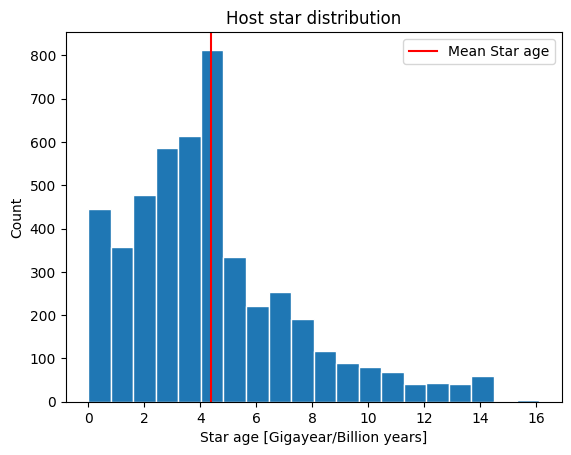

In [19]:
plt.hist(data['star_age_gyr'], bins=20, edgecolor='white')

mean_star_age = data['star_age_gyr'].mean()

plt.title('Host star distribution')

plt.axvline(mean_star_age, color='r', label='Mean Star age')
plt.xlabel('Star age [Gigayear/Billion years]')
plt.ylabel('Count')
plt.legend()
plt.show()